In [18]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm
from scipy.stats import spearmanr

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [19]:
## Single gene-trait association plot
gene_name = 'LDLR'
phenotype = 'ldl_direct_int'
# gene_name = 'APOB'

In [20]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
"""vep_consequences""","""consequence_start_lost""","""#E65100""","""VEP Start Lost""",1
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1


In [ ]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated/annotations_fillna_ukbgym.parquet -o /home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet

anno = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")

min_range = -2000
max_range = +0

anno = (
    anno
    
    .filter(
        # Filter to gene
        (pl.col('gene_name') == gene_name) &

        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)) &

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_5_prime_utr_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('mobi_disorder_full') == True) &

        # Custom variant class filter
        # filter_expression &

        # Choose regulatory region
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &
        
        # Proximity to TSS
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .select(
        set(['id', 'region', 'gene_name']).union(set(existing_annos))
    )
    .collect(engine='streaming')
)

anno

five_prime_utr_variant_consequence_uaug_gained,cadd_raw,verphylop,pangolin_score,absplice2_max,region,five_prime_utr_variant_consequence_ustop_lost,gene_name,five_prime_utr_variant_consequence_ustop_gained,low_complexity_domain,mobi_lip_full,abexp_abs_max,consequence_splice_donor_variant,consequence_synonymous_variant,loftee_hc,consequence_frameshift_variant,mobi_curated_disorder_priority,promoterai,consequence_start_lost,esmscoremissense,five_prime_utr_variant_consequence_uaug_lost,ted_domain,absplice_dna_max,consequence_stop_lost,id,score_pai3d,consequence_splice_acceptor_variant,am_pathogenicity,consequence_missense_variant,loftee_lc,consequence_stop_gained,gpn_score,delta_score
u8,f32,f32,f32,f32,str,u8,str,u8,bool,bool,f32,i8,i8,i8,i8,bool,f32,i8,f32,u8,bool,f32,i8,str,f32,i8,f32,i8,i8,i8,f32,f32
0,0.306268,0.091,0.0,0.000033,"""ENSG00000130164""",0,"""LDLR""",0,false,false,0.005598,0,0,0,0,false,0.0,0,0.0,0,false,0.001,0,"""chr19:11095407:T:C""",0.0,0,0.0,0,0,0,-1.07,0.0
0,0.246444,-0.253,0.0,0.000033,"""ENSG00000130164""",0,"""LDLR""",0,false,false,0.005877,0,0,0,0,false,0.0,0,0.0,0,false,0.001,0,"""chr19:11130405:A:T""",0.0,0,0.0,0,0,0,-0.32,0.0
0,4.619923,4.661,0.0,0.000504,"""ENSG00000130164""",0,"""LDLR""",0,false,false,0.07833,0,0,0,0,false,0.0,0,-12.779,0,true,0.006,0,"""chr19:11116141:G:A""",0.821483,0,0.9647,1,0,0,-6.22,0.0
0,0.215594,0.455,0.08,0.000516,"""ENSG00000130164""",0,"""LDLR""",0,false,false,0.074479,0,0,0,0,false,0.0,0,0.0,0,false,0.004,0,"""chr19:11129445:C:T""",0.0,0,0.0,0,0,0,-1.41,0.18
0,0.17652,0.0,0.0,0.000033,"""ENSG00000130164""",0,"""LDLR""",0,false,false,0.005877,0,0,0,0,false,0.0,0,0.0,0,false,0.001,0,"""chr19:11102026:C:A""",0.0,0,0.0,0,0,0,0.06,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0.558934,0.136,0.01,0.000034,"""ENSG00000130164""",0,"""LDLR""",0,false,false,0.005679,0,0,0,0,false,0.0,0,0.0,0,false,0.001,0,"""chr19:11104150:C:G""",0.0,0,0.0,0,0,0,-1.49,0.0
0,-0.583632,-1.271,0.01,0.000327,"""ENSG00000130164""",0,"""LDLR""",0,false,false,0.040499,0,0,0,0,false,0.0,0,0.0,0,false,0.003,0,"""chr19:11123414:T:C""",0.0,0,0.0,0,0,0,-1.12,0.0
0,-0.314652,-0.854,0.0,0.000033,"""ENSG00000130164""",0,"""LDLR""",0,false,false,0.005877,0,0,0,0,false,0.0,0,0.0,0,false,0.001,0,"""chr19:11096233:C:T""",0.0,0,0.0,0,0,0,1.19,0.0


In [36]:
selected_annos = anno_config_df.filter(
    pl.col('annotation').is_in(['esmscoremissense', 'am_pathogenicity']) 
)['annotation'].to_list()

melted_anno = (
    anno

    .select(
        set(['id', 'region', 'gene_name']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region", "gene_name"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
)

melted_anno

id,region,gene_name,annotation,annotation_score
str,str,str,str,f32
"""chr19:11095407:T:C""","""ENSG00000130164""","""LDLR""","""am_pathogenicity""",0.0
"""chr19:11130405:A:T""","""ENSG00000130164""","""LDLR""","""am_pathogenicity""",0.0
"""chr19:11116141:G:A""","""ENSG00000130164""","""LDLR""","""am_pathogenicity""",0.9647
"""chr19:11129445:C:T""","""ENSG00000130164""","""LDLR""","""am_pathogenicity""",0.0
"""chr19:11102026:C:A""","""ENSG00000130164""","""LDLR""","""am_pathogenicity""",0.0
…,…,…,…,…
"""chr19:11104150:C:G""","""ENSG00000130164""","""LDLR""","""esmscoremissense""",0.0
"""chr19:11123414:T:C""","""ENSG00000130164""","""LDLR""","""esmscoremissense""",0.0
"""chr19:11096233:C:T""","""ENSG00000130164""","""LDLR""","""esmscoremissense""",0.0


In [45]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet -o /home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet

appv = (
    pl.scan_parquet("/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet")
    .filter(pl.col('phenotype') == phenotype)
    .collect(engine='streaming')
)

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique())

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
)

# Merge phenotype data and annotation data
pg_df = (
    appv
    .join(
        melted_anno, 
        on="id", 
        how="inner"
    )
    .join(
        anno.select(['id', 'region', 'gene_name']), 
        on=['id', 'region'], 
        how='inner'
    )
    .join(
        anno_config_df,
        on='annotation'
    )
    .with_columns(
        annotation_score_dircorr = pl.col('annotation_score') * pl.col('annotation_dir')
    )
)

pg_df

Error: path "/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrela
ted_appv_percentiles.parquet" already exists but -f/--overwrite was not set


id,region,phenotype,n_individuals,mean_pheno_value,std_pheno_value,mean_pheno_value_rank,mean_pheno_value_ptile,region_right,gene_name,annotation,annotation_score,gene_name_right,category,color,label,annotation_dir,annotation_score_dircorr
str,str,str,i32,f32,f32,f32,f32,str,str,str,f32,str,str,str,str,i8,f32
"""chr19:11095407:T:C""","""ENSG00000130164""","""ldl_direct_int""",1,0.013867,null,6958.0,0.030826,"""ENSG00000130164""","""LDLR""","""am_pathogenicity""",0.0,"""LDLR""","""missense""","""#feb72d""","""AlphaMissense""",1,0.0
"""chr19:11130405:A:T""","""ENSG00000130164""","""ldl_direct_int""",1,-0.530286,null,2493.0,0.011045,"""ENSG00000130164""","""LDLR""","""am_pathogenicity""",0.0,"""LDLR""","""missense""","""#feb72d""","""AlphaMissense""",1,0.0
"""chr19:11116141:G:A""","""ENSG00000130164""","""ldl_direct_int""",3,1.722589,1.989424,13735.0,0.060849,"""ENSG00000130164""","""LDLR""","""am_pathogenicity""",0.9647,"""LDLR""","""missense""","""#feb72d""","""AlphaMissense""",1,0.9647
"""chr19:11129445:C:T""","""ENSG00000130164""","""ldl_direct_int""",8,-0.243444,1.063121,4186.0,0.018545,"""ENSG00000130164""","""LDLR""","""am_pathogenicity""",0.0,"""LDLR""","""missense""","""#feb72d""","""AlphaMissense""",1,0.0
"""chr19:11102026:C:A""","""ENSG00000130164""","""ldl_direct_int""",3,0.440574,0.328917,10854.0,0.048086,"""ENSG00000130164""","""LDLR""","""am_pathogenicity""",0.0,"""LDLR""","""missense""","""#feb72d""","""AlphaMissense""",1,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr19:11126380:C:T""","""ENSG00000130164""","""ldl_direct_int""",5,-1.040247,1.217353,997.0,0.004417,"""ENSG00000130164""","""LDLR""","""esmscoremissense""",0.0,"""LDLR""","""missense""","""#feb72d""","""ESM1v""",-1,-0.0
"""chr19:11087870:A:G""","""ENSG00000130164""","""ldl_direct_int""",2,-0.234755,0.425291,4257.0,0.01886,"""ENSG00000130164""","""LDLR""","""esmscoremissense""",0.0,"""LDLR""","""missense""","""#feb72d""","""ESM1v""",-1,-0.0
"""chr19:11096233:C:T""","""ENSG00000130164""","""ldl_direct_int""",1,0.59858,null,11627.0,0.05151,"""ENSG00000130164""","""LDLR""","""esmscoremissense""",0.0,"""LDLR""","""missense""","""#feb72d""","""ESM1v""",-1,-0.0


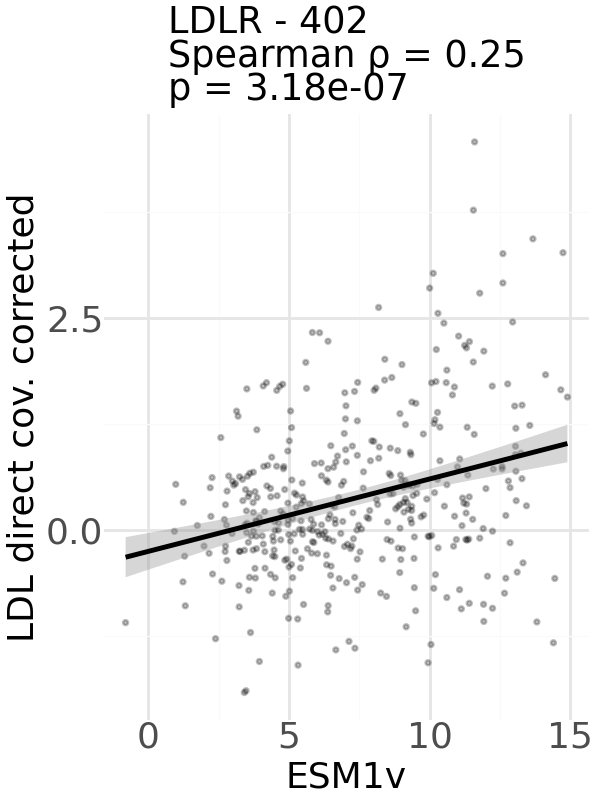

In [46]:
annotation = 'esmscoremissense'
# annotation = 'am_pathogenicity'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

non_zero_median = pg_df.filter(
    (pl.col('annotation') == annotation) &
    (pl.col('annotation_score_dircorr') != 0)
).select(pl.col('annotation_score_dircorr').median()).item()

plot_df = (
    pg_df
    .filter(
        (pl.col('annotation_score_dircorr') != 0) &
        (pl.col('annotation') == annotation)
    )
    # .with_columns(
    #     annotation_score_dircorr = (
    #         pl.when(pl.col('annotation_score_dircorr') == 0)
    #         .then(non_zero_median)
    #         .otherwise(pl.col('annotation_score_dircorr'))
    #     )
    # )
    .drop_nulls(subset=['annotation_score', 'mean_pheno_value'])
)

spearman_corr, p_value = spearmanr(
        plot_df['annotation_score_dircorr'],
        plot_df['mean_pheno_value']
    )

(
    ggplot(plot_df, aes(x='annotation_score_dircorr', y='mean_pheno_value')) +
    geom_point(alpha=0.25, size=0.5, color='black') +
    stat_smooth(method='glm', se=True) +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y="LDL direct cov. corrected",
        title=f"{gene_name} - {plot_df.shape[0]}\nSpearman ρ = {spearman_corr:.2f}\np = {p_value:.2e}"
    ) +
    theme(
        figure_size=(3, 4),
        legend_position='none',
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)